In [1]:
import sys
print("Python:", sys.version)
import pandas as pd; print("pandas:", pd.__version__)
import numpy as np; print("numpy:", np.__version__)
import scipy; print("scipy:", scipy.__version__)
import matplotlib; print("matplotlib:", matplotlib.__version__)
import seaborn as sns; print("seaborn:", sns.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)


Python: 3.12.3 (main, Feb  4 2025, 14:48:35) [GCC 13.3.0]
pandas: 2.3.0
numpy: 2.3.0
scipy: 1.15.3
matplotlib: 3.10.3
seaborn: 0.13.2
scikit-learn: 1.7.0


In [34]:
data_path = "../data/raw/MachineLearningRating_v3.txt"


In [38]:
import pandas as pd
import os

# Use the provided data_path variable
df = pd.read_csv(data_path, sep='|', low_memory=False)


In [42]:
df.head()
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

(1000098, 52)

In [41]:
# Check columns
cols = df.columns.tolist()
print("Columns count:", len(cols))
# Strip whitespace around column names
df.columns = df.columns.str.strip()


Columns count: 52


In [15]:
display(df.head(5))


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [17]:
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')


In [18]:
df['TransactionMonth'].dtype  # should be datetime64[ns]
df['TransactionMonth'].head()


0   2015-03-01
1   2015-05-01
2   2015-07-01
3   2015-05-01
4   2015-07-01
Name: TransactionMonth, dtype: datetime64[ns]

In [19]:
df.info(memory_usage='deep')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[ns]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  object        
 5   LegalType                 1000098 non-null  object        
 6   Title                     1000098 non-null  object        
 7   Language                  1000098 non-null  object        
 8   Bank                      854137 non-null   object        
 9   AccountType               959866 non-null   object        
 10  MaritalStatus             991839 non-null   object        
 11  Gender                    990562 non-null   object

In [20]:
categorical_cols = ['Gender', 'Province', 'VehicleType', 'CoverCategory', 'CoverType', 'MaritalStatus', 'Bank', 'Language', 'Title']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')


In [21]:
# Example: TotalPremium and TotalClaims columns may be parsed as object; convert to float
for col in ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'Kilowatts', 'Cylinders']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


In [22]:
missing = df.isnull().sum().sort_values(ascending=False)
display(missing.head(10))


NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Rebuilt                     641901
Converted                   641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
dtype: int64

In [23]:
# If a column contains strings with spaces signaling missing:
df['Citizenship'] = df['Citizenship'].astype(str).str.strip()
df['Citizenship'].replace({'': pd.NA}, inplace=True)


/tmp/ipykernel_61087/3479961095.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Citizenship'].replace({'': pd.NA}, inplace=True)


In [24]:
df = df[df['TotalPremium'] > 0]  # remove zero or negative premiums if any
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']


In [ ]:
df['HasClaim'] = df['TotalClaims'] > 0


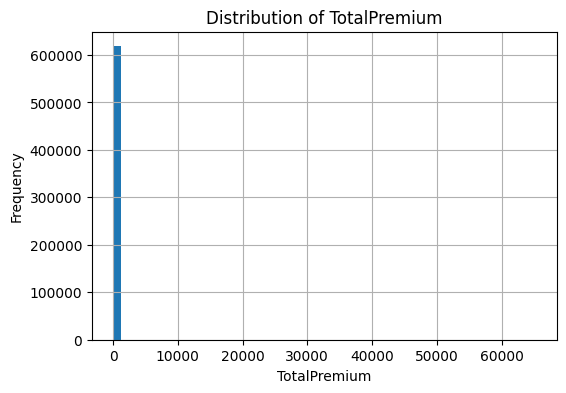

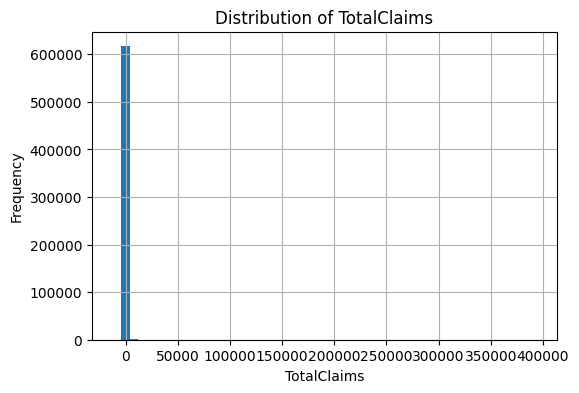

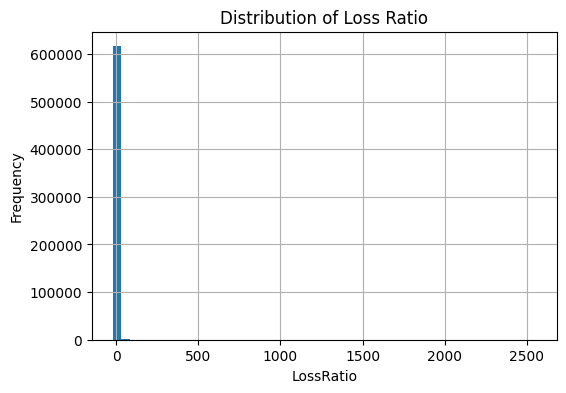

In [26]:
import matplotlib.pyplot as plt
# Histogram of TotalPremium
plt.figure(figsize=(6,4))
df['TotalPremium'].hist(bins=50)
plt.title("Distribution of TotalPremium")
plt.xlabel("TotalPremium")
plt.ylabel("Frequency")
plt.show()
# Histogram of TotalClaims
plt.figure(figsize=(6,4))
df['TotalClaims'].hist(bins=50)
plt.title("Distribution of TotalClaims")
plt.xlabel("TotalClaims")
plt.ylabel("Frequency")
plt.show()
# Histogram of LossRatio
plt.figure(figsize=(6,4))
df['LossRatio'].hist(bins=50)
plt.title("Distribution of Loss Ratio")
plt.xlabel("LossRatio")
plt.ylabel("Frequency")
plt.show()


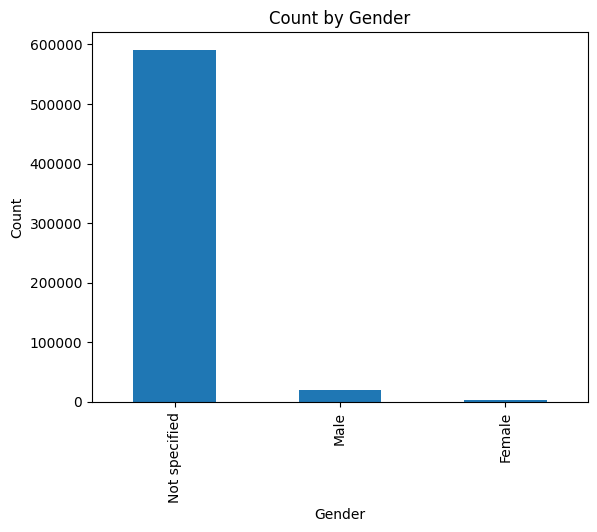

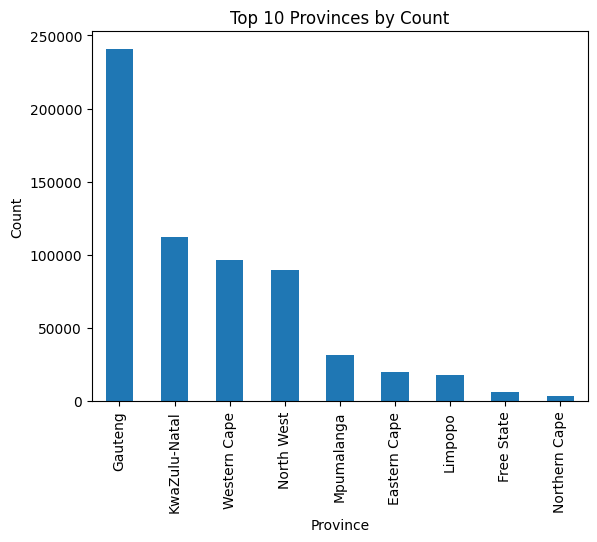

In [ ]:
# Gender distribution
if 'Gender' in df.columns:
    df['Gender'].value_counts().plot(kind='bar')
    plt.title("Count by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.show()
# Province distribution (top 10)
if 'Province' in df.columns:
    df['Province'].value_counts().nlargest(10).plot(kind='bar')
    plt.title("Top 10 Provinces by Count")
    plt.xlabel("Province")
    plt.ylabel("Count")
    plt.show()


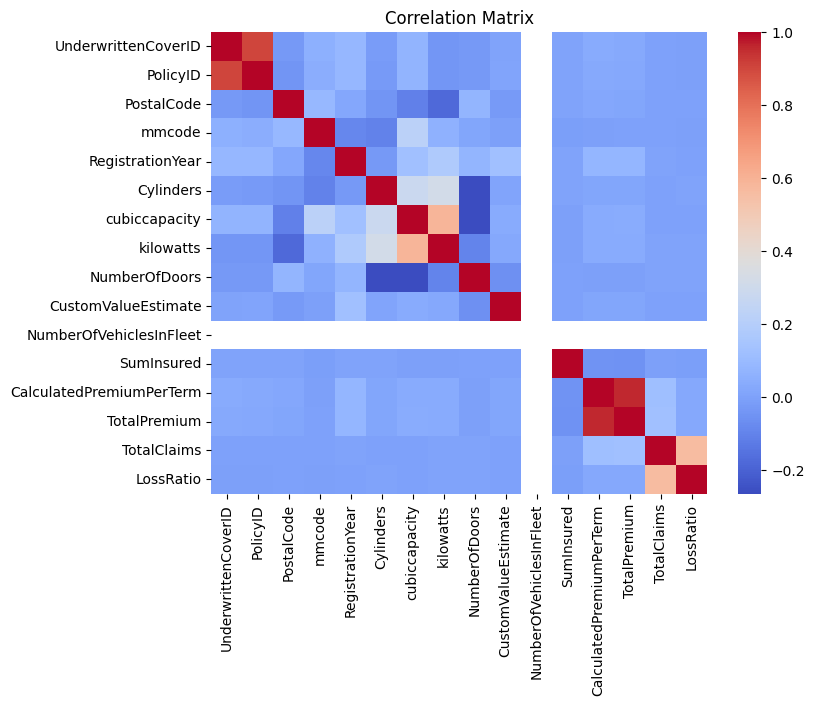

In [ ]:
import seaborn as sns
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


/tmp/ipykernel_61087/441232681.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  province_loss = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)


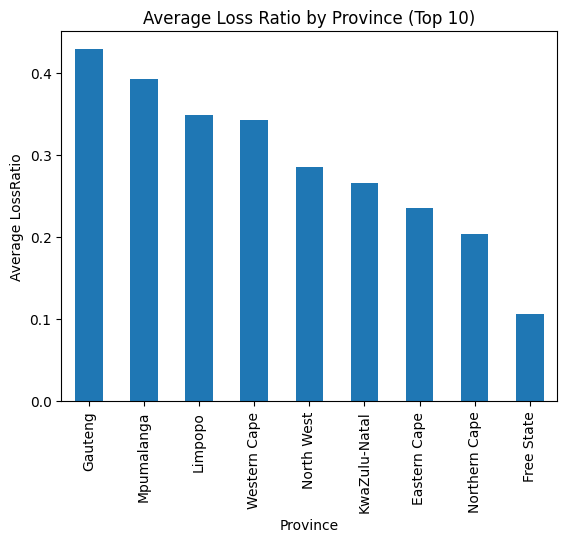

In [29]:
if 'Province' in df.columns:
    province_loss = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
    province_loss.head(10).plot(kind='bar')
    plt.title("Average Loss Ratio by Province (Top 10)")
    plt.ylabel("Average LossRatio")
    plt.show()


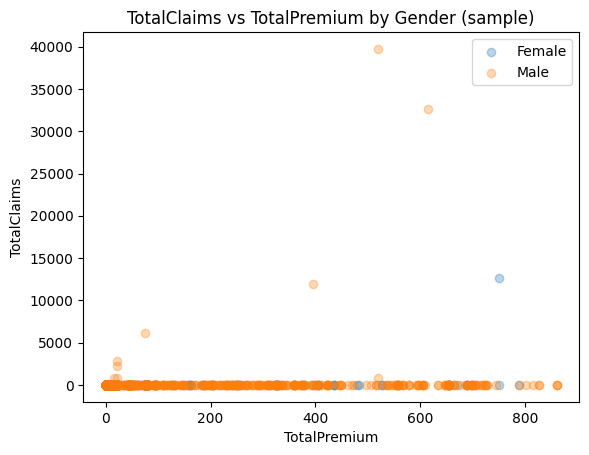

In [30]:
sample = df.sample(n=50000, random_state=42)  # sample 50k for plotting
if 'Gender' in df.columns:
    for gender in sample['Gender'].cat.categories[:2]:  # maybe two categories
        subset = sample[sample['Gender']==gender]
        plt.scatter(subset['TotalPremium'], subset['TotalClaims'], alpha=0.3, label=gender)
    plt.legend()
    plt.title("TotalClaims vs TotalPremium by Gender (sample)")
    plt.xlabel("TotalPremium")
    plt.ylabel("TotalClaims")
    plt.show()


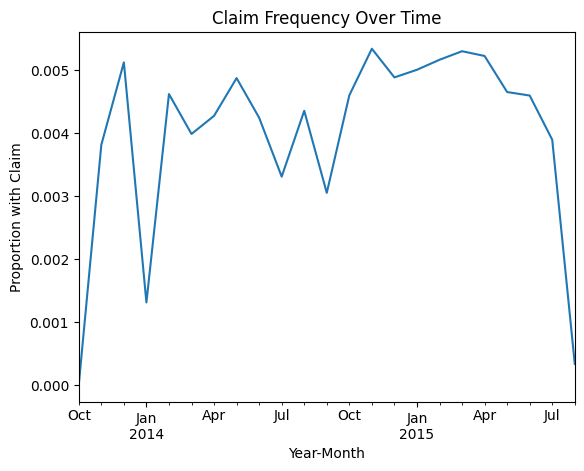

In [31]:
df['YearMonth'] = df['TransactionMonth'].dt.to_period('M')
monthly_claims = df.groupby('YearMonth')['HasClaim'].mean()
monthly_claims.plot()
plt.title("Claim Frequency Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Proportion with Claim")
plt.show()


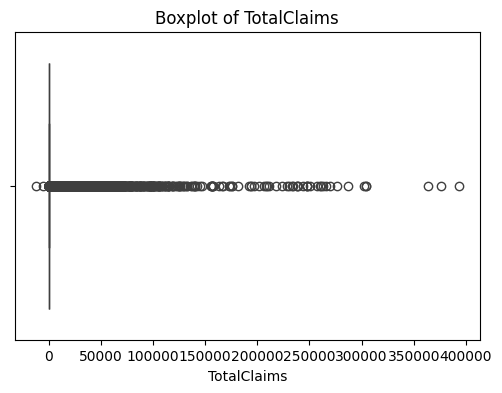

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['TotalClaims'])
plt.title("Boxplot of TotalClaims")
plt.show()


In [33]:
high_claims = df[df['TotalClaims'] > df['TotalClaims'].quantile(0.99)]
display(high_claims.head())



,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,HasClaim,YearMonth
284,82062,7174,2015-03-01,True,<NA>,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,2040.473684,93.045600,True,2015-03
1560,119591,8672,2015-04-01,False,<NA>,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,1213.889211,46492.211754,38.300210,True,2015-04
1779,50193,283,2014-10-01,False,<NA>,Close Corporation,Mr,English,Standard Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,645.017456,26516.859649,41.110298,True,2014-10
1943,119582,8672,2015-04-01,False,<NA>,Close Corporation,Mr,English,First National Bank,Current account,...,Income Protector,Optional Extended Covers,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,74.561404,6140.350877,82.352941,True,2015-04
2072,16821,839,2015-03-01,False,<NA>,Individual,Dr,English,Standard Bank,Savings account,...,Income Protector,Optional Extended Covers,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,74.561404,4385.964912,58.823529,True,2015-03


1. Distribution of TotalPremium (Histogram)
Interpretation:
This histogram displays the distribution of TotalPremium. The most prominent feature is the overwhelming concentration of data points at the lowest end of the TotalPremium scale, specifically around zero. The frequency count for this initial bin is exceptionally high, reaching over 600,000. As the TotalPremium values increase, the frequency of observations drops drastically, with very few, if any, records exhibiting higher premium amounts. This indicates an extremely right-skewed distribution, where a vast majority of entries have very low or possibly zero premium values, and higher premium values are rare occurrences.

2. Distribution of TotalClaims (Histogram)
Interpretation:
Similar to the TotalPremium distribution, this histogram for TotalClaims also exhibits extreme right-skewness. A towering bar at the origin (around zero claims) signifies that the vast majority of data points, exceeding 600,000 records, correspond to very low or zero claim amounts. The frequency of higher TotalClaims values diminishes almost immediately as the claim amount increases, indicating that large claim amounts are exceptionally rare within this dataset.

3. Distribution of Loss Ratio (Histogram)
Interpretation:
The histogram for LossRatio presents a distribution pattern identical to TotalPremium and TotalClaims. An overwhelmingly large number of records show a LossRatio concentrated at or very near zero. This initial bin accounts for over 600,000 observations. Beyond this low range, the frequency of higher LossRatio values becomes negligible. This suggests that for most instances, the claims incurred are very small relative to the premium collected, or that no claims were filed, leading to a low or zero loss ratio. High loss ratios, while present, are extremely infrequent.

4. Count by Gender (Bar Chart)
Interpretation:
This bar chart illustrates the count of entries across different gender categories. A striking observation is the highly imbalanced distribution. The "Not specified" category accounts for nearly 600,000 entries, representing the vast majority of the dataset. In contrast, the "Male" category has a significantly smaller count (appearing to be around 25,000-30,000), and the "Female" category is exceptionally rare, almost indistinguishable from the X-axis, indicating a very low count. This suggests that gender information is largely unrecorded or absent for most of the data points.

5. Top 10 Provinces by Count (Bar Chart)
Interpretation:
This bar chart shows the distribution of records across the top 10 most frequent provinces. The distribution is highly uneven, indicating a significant geographical concentration of data. "Gauteng" is by far the most represented province, with a count close to 240,000 records. "KwaZulu-Natal" and "Western Cape" follow, with considerably lower but still substantial counts (around 110,000 and 98,000 respectively). The counts decline sharply for the remaining provinces, with "Northern Cape" having the lowest representation among the top 10. This highlights that a disproportionate share of the dataset originates from a few key provinces.

6. Average Loss Ratio by Province (Top 10) (Bar Chart)
Interpretation:
This bar chart displays the average LossRatio for the top 10 provinces, ordered from highest to lowest. "Gauteng" exhibits the highest average LossRatio at approximately 0.43, suggesting that, on average, claims costs are highest relative to premiums in this region. "Mpumalanga" and "Limpopo" follow with moderately high average loss ratios (around 0.39 and 0.35 respectively). The average LossRatio gradually decreases across the listed provinces, with "Free State" having the lowest average among the top 10 at just over 0.1. This indicates significant variation in claim performance across different geographical regions, with certain provinces posing higher average risk.

7. TotalClaims vs TotalPremium by Gender (sample) (Scatter Plot)
Interpretation:
This scatter plot visualizes the relationship between TotalClaims and TotalPremium, distinguishing points by "Female" and "Male" genders, based on a sample of the data. The most striking feature is the extremely high density of data points concentrated at the lower left corner (near 0 for both TotalPremium and TotalClaims). This visually confirms that the vast majority of observations involve very low premium amounts and very low or zero claim amounts for both genders. As TotalPremium and TotalClaims increase, the data points become very sparse, indicating that instances of high premiums and high claims are rare. While some very high TotalClaims values are observed, particularly associated with "Male" premiums, and a lone high TotalClaims value for "Female," the overall patterns within this sample are largely dominated by the low-value clusters, making gender-specific trends challenging to discern definitively from this plot alone.

8. Claim Frequency Over Time (Line Plot)
Interpretation:
This line plot illustrates the "Proportion with Claim" (claim frequency) over time, spanning from late 2013 to mid-2015. The overall claim frequency remains very low, ranging from near 0 to just over 0.005 (0.5%). The plot reveals clear temporal patterns:

There's an initial sharp increase from October 2013, followed by a noticeable dip in January 2014.
The frequency fluctuates throughout 2014 and early 2015, showing multiple peaks and troughs, suggesting potential seasonality or cyclical behavior. For instance, peaks are observed around April 2014 and late 2014/early 2015.
A general upward trend in frequency is observed from late 2013 to early 2015, indicating a slight increase in the proportion of claims over this period.
A sharp decline in claim frequency is evident towards the very end of the plotted period, around July 2015. This abrupt drop might signify a real decrease in claims or could be an artifact of data truncation for the last recorded period.
9. Boxplot of TotalClaims (Horizontal Boxplot)
Interpretation:
This horizontal boxplot of TotalClaims provides a concise summary of its distribution, emphasizing its extreme characteristics. The box itself, which represents the interquartile range (Q1 to Q3), is compressed into an almost invisible vertical line precisely at TotalClaims = 0. This indicates that the median, first quartile (Q1), and third quartile (Q3) of TotalClaims are all zero. Consequently, at least 75% of the data points for TotalClaims are exactly zero. The whiskers extending from this compressed box are extremely short. A very long and dense series of individual circular points stretches from just above zero across the entire range of the X-axis (up to nearly 400,000). These points represent all non-zero TotalClaims values, which are considered outliers by the standard boxplot definition due to the concentrated zero values. This plot powerfully confirms the severe positive skewness and the zero-inflated nature of the TotalClaims variable, showing that while most records have no claims, rare instances involve significant claim amounts.